In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch_geometric "scanpy==1.11.4"

## import

In [76]:
import torch
import torch.nn.functional as F

if torch.cuda.is_available():
    device = "cuda"
    print("GPU: ",torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("Using CPU")

Using CPU


In [4]:
##Working with google colab
import os
import sys

os.chdir("/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/GNN")
cwd = os.getcwd()
print(cwd)

sys.path.append("../../")

/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/GNN


In [36]:
import scanpy as sc
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import Normalizer

import matplotlib.pyplot as plt

#plt.rcParams['pdf.fonttype'] = 42
#plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'sans-serif'

pltkw = dict(bbox_inches='tight', transparent=True)

In [59]:
import GNN as SA
import importlib

In [64]:
importlib.reload(SA.dataset)
importlib.reload(SA.model)
importlib.reload(SA)

<module 'GNN' from '/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/GNN/../../GNN/__init__.py'>

## Dataset

In [ ]:
adata = sc.read_h5ad("../../../Data/Breast_Cancer/ann_data.h5ad")

Noise

In [ ]:
rng = np.random.default_rng(42)
ad = adata.copy()
ad.obsm["morpho"] = rng.standard_normal((167780, 500))

In [ ]:
adata.obsm['p_Morpho_Embedding'] = ad.obsm['morpho'] - np.min(ad.obsm['morpho'])

Founsation Models

In [65]:
adata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/UNI_adata.h5ad")

In [ ]:
adata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/hoptimus_adata.h5ad")

In [ ]:
adata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/virchow_adata.h5ad")

Preparing Dataset

In [66]:
adata = SA.prep_adata(adata, norm=True, log1p=True)
data = SA.build_graph(adata, k=8, morph_key='p_Morpho_Embedding')

In [67]:
print(data.x.shape)              # shape of each node
print(data.edge_index[:, :10])   # first 10 edges
print(data.edge_attr[:10])       # first 10 edge features

torch.Size([167780, 813])
tensor([[    0,     2,     0, 46964,     0,   112,     0,     4,     0,     5],
        [    2,     0, 46964,     0,   112,     0,     4,     0,     5,     0]])
tensor([ 5.7527,  5.7527,  6.9007,  6.9007,  8.1722,  8.1722,  8.4531,  8.4531,
        10.4105, 10.4105])


## Analysis




In [68]:
SA.set_random_seed(0)
model = SA.SpatialTransformerAE(
    in_dim=data.x.shape[1],
    gene_dim=data.gene_dim,
    hidden_dim=96,
    latent_dim=64,
    heads=4
)

###

### h_optimus

In [ ]:
model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_hoptimus_0.8.pth',weights_only=True, map_location=torch.device('cpu')))

<All keys matched successfully>

In [ ]:
## h_optimus
model = model.to(device)
data = data.to(device)

with torch.no_grad():

  x_masked = mask_features(data, 0.8)
  out = model(x_masked, data.edge_index, data.edge_attr)
  loss = loss_fn(out, data.x, data.gene_dim)
  print(loss)

tensor(0.1090)


### UNI

In [81]:
model.load_state_dict(torch.load(f'saved_models/MI_MR_0.8_Seed_0.pth',weights_only=True, map_location=torch.device(device)))

<All keys matched successfully>

In [82]:
## UNI
model = model.to(device)
data = data.to(device)

with torch.no_grad():
  x = data.x.clone()
  out, z = model(x, data.edge_index, data.edge_attr, details=True)

In [79]:
ad = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/UNI_adata.h5ad")

In [19]:
mask1 = (ad.obs['annotation'] == "DCIS_1") & (ad.obs['cell_type'] == "T_Cell_&_Tumor_Hybrid")
mask2 = (ad.obs['annotation'] == "DCIS_2") & (ad.obs['cell_type'] == "T_Cell_&_Tumor_Hybrid")
mask3 = (ad.obs['annotation'] == "DCIS_1")  & (ad.obs['cell_type'] == "Invasive_Tumor")
mask4 = (ad.obs['annotation'] == "DCIS_2")  & (ad.obs['cell_type'] == "Invasive_Tumor")

In [24]:
X = ad.X.toarray()

# group-level gene expression vectors (mean across cells)
g1 = X[mask1].mean(axis=0)
g2 = X[mask2].mean(axis=0)
g3 = X[mask3].mean(axis=0)
g4 = X[mask4].mean(axis=0)


group_matrix0 = pd.DataFrame({
    "DCIS_1 & T_cell": g1,
    "DCIS_2 & T_cell": g2,
    "DCIS_1 & Tumor": g3,
    "DCIS_2 & Tumor": g4
})

In [25]:
X = ad.obsm['p_Morpho_Embedding']

# group-level gene expression vectors (mean across cells)
g1 = X[mask1].mean(axis=0)
g2 = X[mask2].mean(axis=0)
g3 = X[mask3].mean(axis=0)
g4 = X[mask4].mean(axis=0)


group_matrix1 = pd.DataFrame({
    "DCIS_1 & T_cell": g1,
    "DCIS_2 & T_cell": g2,
    "DCIS_1 & Tumor": g3,
    "DCIS_2 & Tumor": g4
})

In [26]:
X = z.cpu().detach().numpy()

# group-level gene expression vectors (mean across cells)
g1 = X[mask1].mean(axis=0)
g2 = X[mask2].mean(axis=0)
g3 = X[mask3].mean(axis=0)
g4 = X[mask4].mean(axis=0)


group_matrix2 = pd.DataFrame({
    "DCIS_1 & T_cell": g1,
    "DCIS_2 & T_cell": g2,
    "DCIS_1 & Tumor": g3,
    "DCIS_2 & Tumor": g4
})

In [40]:
X = z.cpu().detach().numpy()

# group-level gene expression vectors (mean across cells)
g1 = X[mask1].mean(axis=0)
g2 = X[mask2].mean(axis=0)
g3 = X[mask3].mean(axis=0)
g4 = X[mask4].mean(axis=0)


group_matrix3 = pd.DataFrame({
    "DCIS_1 & T_cell": g1,
    "DCIS_2 & T_cell": g2,
    "DCIS_1 & Tumor": g3,
    "DCIS_2 & Tumor": g4
})

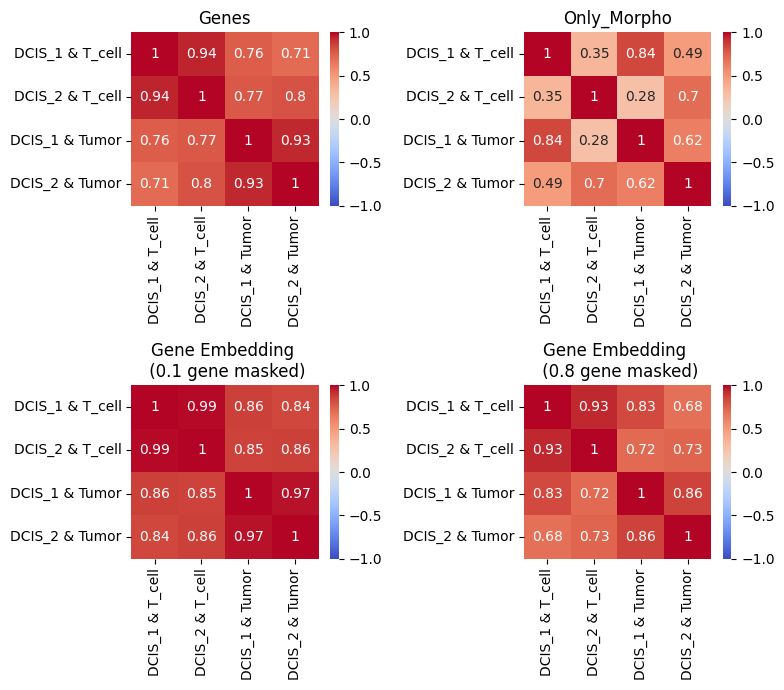

In [47]:
import seaborn as sns

corr1 = group_matrix0.corr()
corr2 = group_matrix1.corr()
corr3 = group_matrix2.corr()
corr4 = group_matrix3.corr()

fig, axes = plt.subplots(2, 2, figsize=(8, 7))

sns.heatmap(corr1, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0,0])
axes[0,0].set_title("Genes")

sns.heatmap(corr2, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0,1])
axes[0,1].set_title("Only_Morpho")

sns.heatmap(corr3, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1,0])
axes[1,0].set_title("Gene Embedding \n (0.1 gene masked)")

sns.heatmap(corr4, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1,1])
axes[1,1].set_title("Gene Embedding \n (0.8 gene masked)")

plt.tight_layout()
plt.show()

In [80]:
X = z.cpu().detach().numpy()

# group-level gene expression vectors (mean across cells)
g1 = X[mask1].mean(axis=0)
g2 = X[mask2].mean(axis=0)
g3 = X[mask3].mean(axis=0)
g4 = X[mask4].mean(axis=0)


group_matrix4 = pd.DataFrame({
    "DCIS_1 & T_cell": g1,
    "DCIS_2 & T_cell": g2,
    "DCIS_1 & Tumor": g3,
    "DCIS_2 & Tumor": g4
})

In [83]:
X = z.cpu().detach().numpy()

# group-level gene expression vectors (mean across cells)
g1 = X[mask1].mean(axis=0)
g2 = X[mask2].mean(axis=0)
g3 = X[mask3].mean(axis=0)
g4 = X[mask4].mean(axis=0)


group_matrix5 = pd.DataFrame({
    "DCIS_1 & T_cell": g1,
    "DCIS_2 & T_cell": g2,
    "DCIS_1 & Tumor": g3,
    "DCIS_2 & Tumor": g4
})

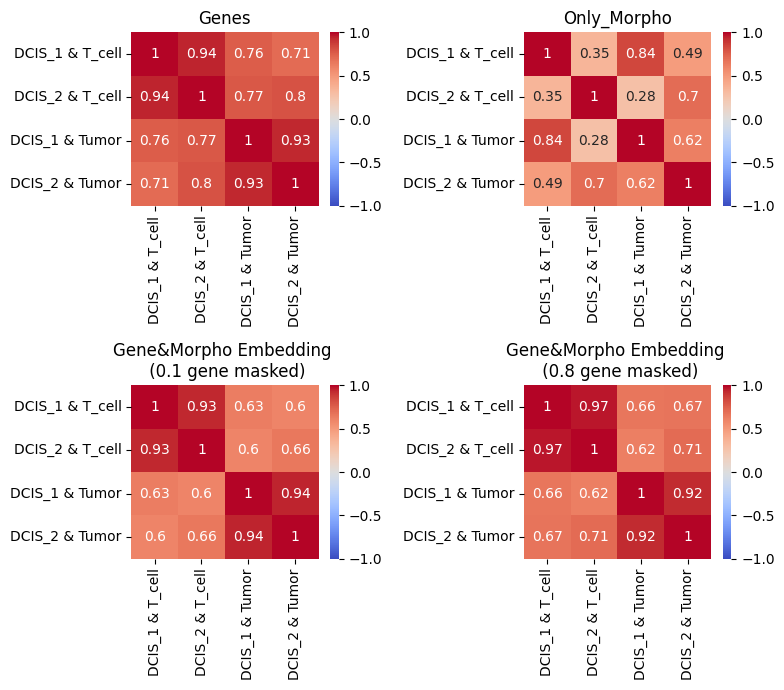

In [84]:
import seaborn as sns

corr1 = group_matrix0.corr()
corr2 = group_matrix1.corr()
corr3 = group_matrix4.corr()
corr4 = group_matrix5.corr()

fig, axes = plt.subplots(2, 2, figsize=(8, 7))

sns.heatmap(corr1, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0,0])
axes[0,0].set_title("Genes")

sns.heatmap(corr2, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0,1])
axes[0,1].set_title("Only_Morpho")

sns.heatmap(corr3, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1,0])
axes[1,0].set_title("Gene&Morpho Embedding \n (0.1 gene masked)")

sns.heatmap(corr4, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1,1])
axes[1,1].set_title("Gene&Morpho Embedding \n (0.8 gene masked)")

plt.tight_layout()
plt.show()